# EC-1: Cross-Encoder Reranking for Biomedical Literature Retrieval

**Conversational AI (AIMLCZG521) — EC-1 Assessment, Problem Statement 2**


## Student Details

> **[FILL IN BEFORE SUBMISSION]**
> Name:
> BITS ID:
> Assignment Set: PS2 (confirm against the allotted set before submission)


## Problem Statement

Build and evaluate a **two-stage retrieval system** for biomedical literature:

1. **Stage 1 — initial retrieval.** Given a natural-language research query, retrieve
   a candidate pool of documents from a biomedical corpus using lexical (BM25),
   dense (bi-encoder), and hybrid (Reciprocal Rank Fusion) methods.
2. **Stage 2 — cross-encoder reranking.** Rerank the Stage-1 candidate pool with a
   pretrained cross-encoder that scores each (query, document) pair jointly, and
   evaluate whether reranking improves ranking quality — and at what latency cost.

**Scope statement.** This system performs *literature retrieval* — ranking research
abstracts by relevance to a query. It does **not** provide medical diagnosis,
treatment recommendations, or patient-specific medical advice, and must not be used
for those purposes.


## Dataset Details and Source

**Dataset:** [BEIR](https://github.com/beir-cellar/beir) / **SciFact**
(Wadden et al., 2020), accessed via HuggingFace `BeIR/scifact` and `BeIR/scifact-qrels`.

| Property | Value |
|---|---|
| Domain | Biomedical / scientific claim verification |
| Corpus | 5,183 research abstracts (after dedup) |
| Queries | 300 test-split claims |
| Relevance labels | Binary; almost every query has **exactly one** relevant document |
| Split used | `test` |

**Why SciFact:** small enough to run entirely on CPU, genuinely biomedical, has real
(not synthetic) relevance judgments, and is a standard BEIR benchmark — citable and
comparable to published numbers.

**Binary-label caveat — read this before any metric number in this notebook.**
Because most queries have exactly one relevant document:

| Metric | What it actually measures here |
|---|---|
| **Precision@5** | Capped at **0.20**. Report as a fraction of that ceiling, not as an absolute score. |
| **Recall@5** | Degenerates to a **hit-rate**: 1.0 if the answer is in the top 5, else 0.0. |
| **MRR** | The genuinely informative metric — *where* the answer landed. |
| **nDCG@5** | With binary gains, reduces to a **position-discount** measure. |

A raw P@5 of ~0.16–0.19 is not a "poor" score — it is close to the 0.20 ceiling.


In [1]:
import json
import os
import sys
from pathlib import Path

# The notebook lives in notebooks/; every path in config/experiment.yaml is relative
# to the project root, so we chdir there once, up front, rather than resolving paths
# relative to the notebook everywhere downstream.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.config import load_config

cfg = load_config()
print("Config loaded. Seed:", cfg.get("seed"))
print("Dataset:", cfg.get("dataset.hf_id"), "| split:", cfg.get("dataset.split"))


Config loaded. Seed: 42
Dataset: BeIR/scifact | split: test


In [2]:
corpus = pd.read_parquet(cfg.get("dataset.processed_dir") + "/corpus.parquet")
queries = pd.read_parquet(cfg.get("dataset.processed_dir") + "/queries.parquet")
qrels = pd.read_parquet(cfg.get("dataset.processed_dir") + "/qrels.parquet")

print(f"Corpus:  {len(corpus):,} documents")
print(f"Queries: {len(queries):,} test queries")
print(f"Qrels:   {len(qrels):,} relevance judgments")
print(f"Avg relevant docs / query: {len(qrels) / len(queries):.2f}")
corpus.head(3)


Corpus:  5,183 documents
Queries: 300 test queries
Qrels:   339 relevance judgments
Avg relevant docs / query: 1.13


,doc_id,title,text_raw,text_norm,n_tokens,has_abbrev
0,4983,Microstructural development of human newborn c...,Microstructural development of human newborn c...,microstructural development of human newborn c...,295,True
1,5836,Induction of myelodysplasia by myeloid-derived...,Induction of myelodysplasia by myeloid-derived...,induction of myelodysplasia by myeloid-derived...,208,True
2,7912,"BC1 RNA, the transcript from a master gene for...","BC1 RNA, the transcript from a master gene for...","bc1 rna, the transcript from a master gene for...",200,True


## Tools and Libraries Used

| Library | Role |
|---|---|
| `datasets` (HuggingFace) | Load BEIR SciFact |
| `pandas` / `pyarrow` | Data wrangling, parquet I/O |
| `transformers` | `AutoTokenizer`, `AutoModelForSequenceClassification` for the cross-encoder |
| `sentence-transformers` | Dense bi-encoder retrieval |
| `torch` | Model inference (MPS on Apple Silicon, else CPU) |
| `rank_bm25`, `pytrec_eval`, `scipy` | **Parity oracles only** — never used in the pipeline itself (General Instruction 9); our BM25, metrics, and significance tests are hand-implemented and asserted equal to these |
| `matplotlib` | Figures |
| `pytest` | Unit + parity test suite |

All model names, hyperparameters, and paths are centralised in `config/experiment.yaml`
— see `src/config.py`. This is the single source of truth referenced throughout.


In [3]:
from src.utils.manifest import build_manifest

print(json.dumps(build_manifest("notebook_env_check")["libraries"], indent=2))


{
  "numpy": "1.26.4",
  "pandas": "2.2.3",
  "torch": "2.5.1",
  "transformers": "4.46.3",
  "sentence_transformers": "3.3.1",
  "rank_bm25": "unknown",
  "pytrec_eval": "0.5.6",
  "scipy": "1.14.1"
}


## Architecture and Workflow

The system is a two-stage cascade: a cheap Stage-1 retriever narrows the corpus to a
candidate pool, and an expensive Stage-2 cross-encoder reorders only that pool.

**Figure 1 — end-to-end architecture** (see `docs/ARCHITECTURE.md` §2 for the full
diagram with the offline/online/evaluation subgraphs). The key structural fact: a
cross-encoder cannot be Stage 1, because scoring one pair costs a full transformer
forward pass, and doing that for the whole corpus does not scale. Stage 1 reduces
5,183 documents to K candidates using a scorer that never sees the query and document
jointly; Stage 2 spends its expensive joint-attention budget only on those K.

**The consequence that governs the whole evaluation:** Stage 2 can only *reorder*
what Stage 1 returned. If the relevant document never made it into the Top-K pool, no
reranker can recover it — Recall@K of the candidate pool is therefore reported as a
hard ceiling before any reranking number (§ Task 5 below).


---
# Task 1 — Data Preparation

**Build:** `src/data_prep.py` — load, dedup, clean, and dual-view the corpus. See
`docs/ARCHITECTURE.md` §4.1 for the full rationale.


In [4]:
# data_prep.py has already been run to produce data/processed/*.parquet (loaded in
# the Dataset Details section above). Re-running it here would re-download SciFact;
# instead this cell reproduces its printed summary from the same cleaning stats logic.
from src.data_prep import CleaningStats, find_ambiguous_abbreviations

n_over_512 = (corpus["n_tokens"] > 512).mean() * 100
print("=== Task 1 cleaning summary (see src/data_prep.py for the full pipeline) ===")
print(f"Corpus size (after dedup): {len(corpus):,}")
print(f"Docs with >=1 abbreviation: {corpus['has_abbrev'].sum():,} "
      f"({100 * corpus['has_abbrev'].mean():.1f}%)")
print()
print("Token-length distribution (text_raw, whitespace-split):")
print(corpus["n_tokens"].describe())
print(f"\n% of docs exceeding 512 tokens (sets up Task 3/7's truncation problem): {n_over_512:.1f}%")


=== Task 1 cleaning summary (see src/data_prep.py for the full pipeline) ===
Corpus size (after dedup): 5,183
Docs with >=1 abbreviation: 4,184 (80.7%)

Token-length distribution (text_raw, whitespace-split):
count    5183.000000
mean      213.935944
std        86.856626
min        33.000000
25%       158.000000
50%       204.000000
75%       260.000000
max      1541.000000
Name: n_tokens, dtype: float64

% of docs exceeding 512 tokens (sets up Task 3/7's truncation problem): 0.7%


In [5]:
print("=== Sample ambiguous abbreviations from this corpus ===")
for cand in find_ambiguous_abbreviations(corpus, top_n=5):
    print(cand)


=== Sample ambiguous abbreviations from this corpus ===
{'abbreviation': 'GSC', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['divisions', 'growth', 'survival']}
{'abbreviation': 'ABPI', 'n_occurrences': 6, 'n_distinct_nearby_words': 6, 'sample_nearby_words': ['between', 'conclusion', 'correlated', 'index', 'were', 'with']}
{'abbreviation': 'MODS', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['against', 'indicators', 'syndrome']}
{'abbreviation': 'YFP', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['expression', 'eyfp', 'reporter']}
{'abbreviation': 'PEPCK', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['carboxykinase', 'enzymes', 'including']}


### Task 1 — Discussion

*(Fill in with measured evidence from the run above — do not restate generic claims
about "medical terminology is hard" without a number from **this** corpus.)*

- **Why preprocessing matters for biomedical retrieval:** BM25 and a transformer
  encoder want *opposite* preprocessing — BM25 matches surface term forms and
  benefits from lowercasing, while a transformer's WordPiece vocabulary and
  pretraining assume natural, cased text (lowercasing destroys the signal that
  distinguishes a gene symbol like *MDM2* from ordinary prose). We therefore keep two
  views, `text_norm` and `text_raw`, rather than compromising on one.
- **Challenges of long scientific abstracts:** [insert the token-length histogram /
  `pct_over_512_tokens` figure printed above — this sets up the 512-token truncation
  problem revisited in Task 7].
- **Medical terminology, abbreviations, named entities:** [insert the count of
  abstracts containing ≥1 all-caps abbreviation, from the run above].
- **Similar terminology in unrelated research (2–3 real examples from our corpus):**
  [insert 2–3 concrete ambiguous-abbreviation examples from
  `find_ambiguous_abbreviations()`'s output above — e.g. an abbreviation with two
  distinct nearby expansion words across different documents].


---
# Task 2 — Initial Search System (Stage 1: BM25, Dense, Hybrid)

**Build:** `src/retrieval/{bm25,dense,hybrid}.py` — BM25 implemented from the
Robertson–Zaragoza formula (not a library call), dense via a sentence-transformer
bi-encoder, hybrid via Reciprocal Rank Fusion. Driver: `src/retrieval/run_stage1.py`.


### BM25-vs-`rank_bm25` parity — evidence for General Instruction 9

Our BM25 is scored from the formula, not from a library. This cell proves it matches
the reference implementation within numerical tolerance.


In [6]:
!python -m pytest tests/test_bm25.py -v 2>&1 | tail -20


============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-8.3.4, pluggy-1.6.0 -- /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank
configfile: pytest.ini
plugins: anyio-4.14.2
collecting ... collected 4 items

tests/test_bm25.py::test_bm25_matches_rank_bm25_scores PASSED            [ 25%]
tests/test_bm25.py::test_bm25_top_k_ranking_matches PASSED               [ 50%]
tests/test_bm25.py::test_tokenizer_lowercases_and_strips_punctuation PASSED [ 75%]
tests/test_bm25.py::test_empty_query_scores_all_zero PASSED              [100%]

============================== 4 passed in 0.05s ===============================


In [7]:
# Full Stage-1 run over all 300 queries (BM25 + dense + hybrid) already executed;
# results/tables/stage1_*.csv is the saved output. Re-run with:
#   .venv/bin/python -m src.retrieval.run_stage1
tables_dir = Path(cfg.get("output.tables_dir"))

stage1_metrics = pd.read_csv(tables_dir / "stage1_metrics.csv")
print("=== Stage 1 metrics @k=5, all 300 queries ===")
display(stage1_metrics)


=== Stage 1 metrics @k=5, all 300 queries ===

,method,precision@5,precision@5_ceiling,recall@5,mrr,ndcg@5,precision@5_pct_of_ceiling,n_queries
0,bm25,0.156000,0.226,0.721778,0.625976,0.635209,0.690265,300.0
1,dense,0.164000,0.226,0.737944,0.611522,0.629551,0.725664,300.0
2,hybrid,0.164667,0.226,0.746167,0.664474,0.669363,0.728614,300.0


In [8]:
stage1_latency = pd.read_csv(tables_dir / "stage1_latency.csv")
print("=== Stage 1 latency (ms), median (p50) and p95 over 5 timed repeats after 3 warmup runs ===")
display(stage1_latency)


=== Stage 1 latency (ms), median (p50) and p95 over 5 timed repeats after 3 warmup runs ===


,operation,p50_ms,p95_ms,mean_ms,min_ms,max_ms,n_runs
0,bm25,3.149,3.244,3.100,2.811,3.260,5
1,dense,8.425,9.254,8.585,8.057,9.333,5
2,hybrid,13.411,17.096,14.278,12.333,17.542,5


In [9]:
stage1_ceiling = pd.read_csv(tables_dir / "stage1_recall_ceiling.csv")
print("=== Recall@K of each Stage-1 candidate pool — the reranking headroom ===")
display(stage1_ceiling.pivot(index="k", columns="method", values="recall@k"))


=== Recall@K of each Stage-1 candidate pool — the reranking headroom ===


method,bm25,dense,hybrid
k,,,
5,0.721778,0.737944,0.746167
10,0.775667,0.786667,0.802556
20,0.831611,0.837333,0.873056
50,0.865722,0.892000,0.939667
100,0.876389,0.925000,0.957000


### Lexical mismatch and semantic drift — concrete examples

`src/retrieval/run_stage1.py` mines these automatically:
- **Lexical mismatch**: the relevant document is missing/low from BM25 (surface-term
  matching) but present/high in dense retrieval (semantic similarity) — a synonym or
  paraphrase BM25's exact-term matching cannot bridge.
- **Semantic drift**: dense retrieval ranks a *non-relevant* but topically-similar
  document highly — the failure mode a bi-encoder is prone to since it can only
  compare independently-produced summaries, never the query and document jointly.


In [10]:
lexical_mismatch = pd.read_csv(tables_dir / "stage1_lexical_mismatch.csv")
print("=== Lexical mismatch candidates (BM25 misses, dense finds) ===")
display(lexical_mismatch)


=== Lexical mismatch candidates (BM25 misses, dense finds) ===


,query_id,query,doc_id,doc_title,bm25_rank,dense_rank
0,1,0-dimensional biomaterials show inductive prop...,31715818,New opportunities: the use of nanotechnologies...,not in top-100,5
1,133,Assembly of invadopodia is triggered by focal ...,17934082,Membrane lipids in invadopodia and podosomes: ...,22,3
2,179,Birth-weight is positively associated with bre...,27123743,Role of birthweight in the etiology of breast ...,not in top-100,1
3,179,Birth-weight is positively associated with bre...,23557241,Intrauterine factors and risk of breast cancer...,20,5
4,238,Cells undergoing methionine restriction may ac...,2251426,microRNAs: A Safeguard against Turmoil?,20,2


In [11]:
semantic_drift = pd.read_csv(tables_dir / "stage1_semantic_drift.csv")
print("=== Semantic drift candidates (dense ranks highly, not relevant) ===")
display(semantic_drift)


=== Semantic drift candidates (dense ranks highly, not relevant) ===


,query_id,query,doc_id,doc_title,dense_rank
0,1,0-dimensional biomaterials show inductive prop...,29638116,Complex Tissue and Disease Modeling using hiPSCs.,1
1,1,0-dimensional biomaterials show inductive prop...,4346436,Nonlinear Elasticity in Biological Gels,2
2,1,0-dimensional biomaterials show inductive prop...,3874000,Tissue Mechanics Orchestrate Wnt-Dependent Hum...,3
3,3,"1,000 genomes project enables mapping of genet...",2739854,Rare and common variants: twenty arguments,1
4,3,"1,000 genomes project enables mapping of genet...",23389795,Common and rare variants in multifactorial sus...,2


### Task 2 — Discussion

*(Fill in — pick one concrete row from each table above and narrate it.)*

- **Advantages / limitations per method:**
  - *BM25* — exact surface-term matching; fast, interpretable, no training needed;
    fails on synonyms/paraphrase (see lexical-mismatch example above).
  - *Dense* — captures semantic similarity beyond exact wording; can drift toward
    topically-similar but irrelevant documents (see semantic-drift example above),
    since the query and document are encoded independently and never compared jointly.
  - *Hybrid (RRF)* — combines both signals by rank position (score-scale-agnostic);
    [insert observation from the recall-ceiling table above — did hybrid dominate
    both single methods at every K?].
- **A concrete lexical-mismatch case:** [walk through one row of the table above —
  query text, the relevant doc's BM25 rank vs. dense rank, and why the surface terms
  didn't overlap].
- **A concrete semantic-drift case:** [walk through one row of the table above — why
  the topically-similar document was *not* actually relevant].
- **A relevant-but-lower-ranked case:** [pick a query where the relevant doc appears
  in the pool but outside the top few ranks, and discuss why].


---
# Task 3 — Cross-Encoder Reranking (Stage 2)

**Build:** `src/rerank/cross_encoder.py` — calls `AutoTokenizer` and
`AutoModelForSequenceClassification` **directly**, not the `CrossEncoder.predict()`
convenience wrapper. The next cells show the manual tokenization and logit
extraction — this is the "demonstrate conceptual understanding" requirement, made
concrete rather than asserted.

**Figure 2 — bi-encoder vs. cross-encoder** (`docs/ARCHITECTURE.md` §5). *Analogy:* a
bi-encoder is two people writing summaries in separate rooms and comparing them
afterward; a cross-encoder is one person reading the query and the document side by
side. The bi-encoder's document vectors are precomputable offline — that is exactly
what lets Stage 1 scale to the whole corpus. The cross-encoder runs a full forward
pass *per pair*, so its cost is O(K) per query, and it can never be Stage 1.


### Worked single-query trace

One query walked end-to-end: its Stage-1 hybrid top-K, the constructed
`[CLS] query [SEP] doc [SEP]` sequence, the actual `input_ids`, and the
manually-extracted logit for the top candidate.


In [12]:
trace = json.loads((tables_dir / "stage2_trace.json").read_text())

print("Query:", trace["query"])
print("Hybrid top-K doc ids:", trace["hybrid_top_k_doc_ids"][:10], "...")
print()
print("Traced doc:", trace["traced_doc_id"])
print("n_tokens_before_truncation:", trace["n_tokens_before_truncation"], "| was_truncated:", trace["was_truncated"])
print()
print("First 20 tokens: ", trace["tokens"][:20])
print("First 20 input_ids:", trace["input_ids"][:20])
print()
print("Manually-extracted relevance logit:", trace["logit"])


Query: 0-dimensional biomaterials show inductive properties.
Hybrid top-K doc ids: ['803312', '43385013', '40212412', '25404036', '10607877', '6863070', '16939583', '29638116', '10608397', '4346436'] ...

Traced doc: 803312
n_tokens_before_truncation: 252 | was_truncated: False

First 20 tokens:  ['[CLS]', '0', '-', 'dimensional', 'bio', '##mate', '##rial', '##s', 'show', 'ind', '##uc', '##tive', 'properties', '.', '[SEP]', 'cerebral', 'organ', '##oids', 'model', 'human']
First 20 input_ids: [101, 1014, 1011, 8789, 16012, 8585, 14482, 2015, 2265, 27427, 14194, 6024, 5144, 1012, 102, 18439, 5812, 17086, 2944, 2529]

Manually-extracted relevance logit: -10.418539047241211


### Stage-1 hybrid vs. Stage-2 reranked (pool = top-20, MS-MARCO MiniLM-L-6)


In [13]:
stage2_metrics = pd.read_csv(tables_dir / "stage2_metrics.csv")
display(stage2_metrics)

stage2_latency = pd.read_csv(tables_dir / "stage2_latency.csv")
print("Reranking latency at pool size 20:")
display(stage2_latency)


,method,precision@5,precision@5_ceiling,recall@5,mrr,ndcg@5,precision@5_pct_of_ceiling,n_queries
0,stage1_hybrid,0.164667,0.226,0.746167,0.662494,0.669363,0.728614,300.0
1,stage2_reranked,0.162000,0.226,0.734500,0.660731,0.660035,0.716814,300.0


Reranking latency at pool size 20:


,operation,p50_ms,p95_ms,mean_ms,min_ms,max_ms,n_runs
0,rerank_k20,139.906,143.172,140.466,138.728,143.793,5


### Task 3 — Discussion

*(Fill in — the analogies above are a starting point, not a substitute for
referencing the actual trace and numbers.)*

- **Bi-encoder vs. cross-encoder:** [reference Figure 2 and the analogy above; state
  precomputability as the concrete reason Stage 1 scales and Stage 2 does not].
- **How the cross-encoder models query-doc interaction:** [reference the printed
  `input_ids`/tokens above — every query token can attend to every document token
  because they are one sequence, not two independently-produced vectors].
- **Why cross-encoders are useful for reranking:** [joint attention → higher
  accuracy than independent-embedding comparison; tie to the metrics table above].
- **Why reranking is applied only to a small candidate set:** [O(K) forward passes
  per query — reference the latency table above and how it would scale to the full
  5,183-document corpus].
- **How biomedical terminology affects relevance scoring:** [preview: this is
  answered quantitatively in Task 6 by comparing MiniLM-L6 against MedCPT].


---
# Task 4 — Before vs. After Reranking: Five Distinct Cases

**Build:** `src/analysis/rank_deltas.py` computes, for every (query, doc) pair,
`rank_stage1`, `rank_ce`, `delta`, `is_relevant`, and `was_truncated`, then
auto-selects one candidate query per required case using the fixed rules below —
machine finds candidates, human explains them. Each case is drawn from a **distinct**
query id by construction.

| Required case | Selection rule |
|---|---|
| Relevant promoted | `is_relevant` and `rank_stage1 > 5` and `rank_ce <= 3` |
| Irrelevant demoted | `not is_relevant` and `rank_stage1 <= 3` and `rank_ce > 5` |
| Minimal change | max `abs(delta)` over top-5 `<= 1` |
| Failure | per-query `nDCG@5_ce < nDCG@5_stage1` |
| Terminology/abbreviation | query matches abbreviation regex, sorted by `abs(delta)` |


In [14]:
selected_cases = pd.read_csv(tables_dir / "task4_selected_cases.csv")
display(selected_cases)


,case,query_id,note,query_raw
0,relevant_promoted,1368,doc 2425364 moved rank 14->1,Vitamin D deficiency effects the term of deliv...
1,irrelevant_demoted,238,doc 4463811 moved rank 2->20,Cells undergoing methionine restriction may ac...
2,minimal_change,1012,max |delta| in top-5 = 1,Radioiodine treatment of non-toxic multinodula...
3,failure,324,nDCG@5 dropped by 1.000,Deleting Raptor reduces G-CSF levels.
4,terminology_abbreviation,936,"query contains abbreviation, max |delta| = 18",Peroxynitrite is required for nitration of TCR...


In [15]:
rank_deltas = pd.read_csv(tables_dir / "task4_rank_deltas.csv")

for _, case in selected_cases.iterrows():
    print(f"=== Case: {case['case']}  (query {case['query_id']}) ===")
    print("Query:", case["query_raw"])
    print("Note:", case["note"])
    qrows = rank_deltas[rank_deltas["query_id"] == case["query_id"]].sort_values("rank_stage1")
    display(qrows.head(8)[["doc_id", "doc_title", "rank_stage1", "rank_ce", "delta", "is_relevant", "was_truncated"]])
    print()


=== Case: relevant_promoted  (query 1368) ===
Query: Vitamin D deficiency effects the term of delivery.
Note: doc 2425364 moved rank 14->1


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
748,23267371,"Vitamin D: The ""sunshine"" vitamin.",1,3,-2,False,False
750,30720103,"Vitamin D status: measurement, interpretation,...",2,11,-9,False,False
746,9555784,Vitamin d deficiency in postmenopausal women -...,3,5,-2,False,False
755,3150030,"Global vitamin D levels in relation to age, ge...",4,10,-6,False,False
749,8856690,Molecular Mechanisms of Vitamin D Action,5,2,3,False,False
759,21553394,Vitamin D and obesity: current perspectives an...,6,6,0,False,False
752,13312471,Vitamin D insufficiency and the blunted PTH re...,7,4,3,False,False
757,36960449,Estimation of the dietary requirement for vita...,8,13,-5,False,False



=== Case: irrelevant_demoted  (query 238) ===
Query: Cells undergoing methionine restriction may activate miRNAs.
Note: doc 4463811 moved rank 2->20


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
4484,28704738,"miR-294/miR-302 promotes proliferation, suppre...",1,2,-1,False,False
4481,4463811,Low methionine ingestion by rats extends life ...,2,20,-18,False,False
4491,6820680,Engineered RNA viral synthesis of microRNAs.,3,12,-9,False,False
4496,2251426,microRNAs: A Safeguard against Turmoil?,4,10,-6,True,False
4493,21909315,Viruses and microRNAs,5,8,-3,False,False
4492,32556431,Virus-encoded microRNAs.,6,16,-10,False,False
4490,12440953,Roles for MicroRNAs in Conferring Robustness t...,7,19,-12,False,False
4487,42662816,Endogenous miRNA sponge lincRNA-RoR regulates ...,8,9,-1,False,False



=== Case: minimal_change  (query 1012) ===
Query: Radioiodine treatment of non-toxic multinodular goitre reduces thyroid volume.
Note: max |delta| in top-5 = 1


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
24,9745001,Radioiodine treatment of multinodular non-toxi...,1,1,0,True,False
37,43122426,131-I radioiodine therapy for hyperthyroidism ...,2,3,-1,False,False
30,26026009,Magnetic resonance imaging for volume estimati...,3,2,1,False,False
26,6751418,Dosimetry and risk estimates of radioiodine th...,4,4,0,False,False
36,37912677,Dose-response study on thyrotoxic patients und...,5,5,0,False,False
29,25452937,Increased density of tumor-associated macropha...,6,13,-7,False,False
27,21551568,Genetic alterations and their relationship in ...,7,14,-7,False,False
25,3944632,Stereotactic radiosurgery plus whole-brain rad...,8,9,-1,False,False



=== Case: failure  (query 324) ===
Query: Deleting Raptor reduces G-CSF levels.
Note: nDCG@5 dropped by 1.000


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
3480,2014909,Oncogenic mTOR signaling recruits myeloid-deri...,1,8,-7,True,False
3487,4658268,"Rictor, a Novel Binding Partner of mTOR, Defin...",2,12,-10,False,False
3483,22174015,PI3K-Akt-mTORC1-S6K1/2 axis controls Th17 diff...,3,1,2,False,False
3490,24612804,Requirement of endogenous stem cell factor and...,4,4,0,False,False
3493,23816832,The utility of cerebrospinal fluid analysis in...,5,13,-8,False,False
3492,19510470,Induction of cell cycle entry eliminates human...,6,5,1,False,False
3494,6962472,G*Power 3: a flexible statistical power analys...,7,19,-12,False,False
3486,16472469,Targeting BRCA1 and BRCA2 Deficiencies with G-...,8,9,-1,False,False



=== Case: terminology_abbreviation  (query 936) ===
Query: Peroxynitrite is required for nitration of TCR/CD8.
Note: query contains abbreviation, max |delta| = 18


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
652,5483793,Altered recognition of antigen is a mechanism ...,1,1,0,True,False
658,23100962,Nitric oxide synthase generates superoxide and...,2,5,-3,False,False
642,20457190,Biochemical differences in the alphabeta T cel...,3,7,-4,False,False
649,24069089,TCR stimulation with modified anti-CD3 mAb exp...,4,8,-4,False,False
654,8305686,Interaction of streptavidin-based peptide-MHC ...,5,10,-5,False,False
640,18758057,NSOM/QD-Based Direct Visualization of CD3-Indu...,6,4,2,False,False
659,5914739,Local changes in lipid environment of TCR micr...,7,14,-7,False,False
648,39539647,A direct role for IFN-gamma in regulation of T...,8,15,-7,False,False


### Task 4 — Discussion (hand-annotate each of the five cases above)

*(For each case: why did the ranking change, and is the final ranking more useful to
the user? Both are explicitly required by the brief.)*

1. **Relevant promoted (query above):** [why — likely joint-attention scoring caught
   a semantic match BM25/RRF's rank position missed; more useful, yes — the answer is
   now near the top].
2. **Irrelevant demoted (query above):** [why the cross-encoder correctly
   down-weighted a lexically-similar but off-topic document; more useful, yes].
3. **Minimal change (query above):** [why reranking barely moved anything here — a
   likely explanation is Stage 1 was already well-ordered for this query].
4. **Failure (query above):** [why reranking made things worse — read the doc
   titles/ranks in the table above for a concrete hypothesis; less useful].
5. **Terminology/abbreviation (query above):** [how the abbreviation affected
   scoring — did the cross-encoder resolve or get confused by it?].


---
# Task 5 — Evaluation: Full Run, Significance Testing, Recall Ceiling

**Build:** `src/eval/metrics.py` (hand-rolled P@5, R@5, MRR, nDCG@5) +
`src/eval/significance.py` (hand-rolled paired bootstrap CI and Wilcoxon
signed-rank). Evaluated over **all 300 test queries** (20x the brief's floor of 10).

### Metrics parity — evidence for General Instruction 9


In [16]:
!python -m pytest tests/test_metrics.py tests/test_significance.py -v 2>&1 | tail -30


============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-8.3.4, pluggy-1.6.0 -- /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank
configfile: pytest.ini
plugins: anyio-4.14.2
collecting ... collected 20 items

tests/test_metrics.py::test_precision_at_k_hand_computed PASSED          [  5%]
tests/test_metrics.py::test_precision_ceiling_is_capped_by_relevant_count PASSED [ 10%]
tests/test_metrics.py::test_recall_degenerates_to_hit_rate_with_one_relevant_doc PASSED [ 15%]
tests/test_metrics.py::test_reciprocal_rank_hand_computed PASSED         [ 20%]
tests/test_metrics.py::test_ndcg_perfect_ranking_is_one PASSED           [ 25%]
tests/test_metrics.py::test_ndcg_position_discount PASSED                [ 30%]
tests/test_metrics.py::test_dcg_uses_trec_linear_gain_form PASSED        [ 

**Binary-label caveat — reproduced from the dataset section, stated again here
because it must appear before every metric table (per the implementation plan):**
P@5 is capped at 0.20; R@5 is a hit-rate; MRR is the informative metric; nDCG@5 is a
position-discount measure under binary gains.


In [17]:
stage5_metrics = pd.read_csv(tables_dir / "stage5_metrics_full.csv")
display(stage5_metrics)


,method,precision@5,precision@5_ceiling,recall@5,mrr,ndcg@5,precision@5_pct_of_ceiling,n_queries
0,stage1_hybrid,0.164667,0.226,0.746167,0.662494,0.669363,0.728614,300.0
1,stage2_reranked,0.162000,0.226,0.734500,0.660731,0.660035,0.716814,300.0


In [18]:
per_query_deltas = pd.read_csv(tables_dir / "stage5_per_query_deltas.csv")
print(f"Per-query nDCG@5 delta distribution (stage2 - stage1), n={len(per_query_deltas)} queries:")
print(per_query_deltas["delta"].describe())
per_query_deltas.head(10)


Per-query nDCG@5 delta distribution (stage2 - stage1), n=300 queries:
count    300.000000
mean      -0.009327
std        0.255041
min       -1.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: delta, dtype: float64


,query_id,ndcg@5_stage1,ndcg@5_stage2,delta
0,1,0.000000,0.000000,0.00000
1,100,1.000000,1.000000,0.00000
2,1012,1.000000,1.000000,0.00000
3,1014,1.000000,1.000000,0.00000
4,1019,0.630930,0.630930,0.00000
5,1020,0.500000,0.630930,0.13093
6,1021,0.500000,0.630930,0.13093
7,1024,0.000000,1.000000,1.00000
8,1029,0.765361,0.765361,0.00000
9,1041,0.000000,0.000000,0.00000


In [19]:
significance = json.loads((tables_dir / "stage5_significance.json").read_text())
comp = significance["comparison"]
boot = significance["paired_bootstrap"]
wil = significance["wilcoxon_signed_rank"]

print(f"n_queries={comp['n_queries']}  improved={comp['n_improved']} ({comp['pct_improved']:.1f}%)"
      f"  degraded={comp['n_degraded']} ({comp['pct_degraded']:.1f}%)  unchanged={comp['n_unchanged']}")
print(f"mean_delta={comp['mean_delta']:.4f}")
print()
print(f"Paired bootstrap 95% CI: [{boot['ci_lower']:.4f}, {boot['ci_upper']:.4f}]  significant={boot['significant']}")
print(f"Wilcoxon signed-rank:    z={wil['z']:.3f}  p={wil['p_value']:.4f}  n_nonzero={wil['n_nonzero']}")


n_queries=300  improved=40 (13.3%)  degraded=48 (16.0%)  unchanged=212
mean_delta=-0.0093

Paired bootstrap 95% CI: [-0.0379, 0.0200]  significant=False
Wilcoxon signed-rank:    z=-0.759  p=0.4476  n_nonzero=88


In [20]:
stage5_ceiling = pd.read_csv(tables_dir / "stage5_recall_ceiling.csv")
print("Recall ceiling of the Stage-1 hybrid pool (reranking headroom, carried from Task 2):")
display(stage5_ceiling[["k", "recall@k"]])


Recall ceiling of the Stage-1 hybrid pool (reranking headroom, carried from Task 2):


,k,recall@k
0,5,0.746167
1,10,0.802556
2,20,0.873056
3,50,0.939667
4,100,0.957000


### Task 5 — Discussion

*(This is the most consequential finding in the whole assignment — do not soften it.)*

- **The headline result:** the mean nDCG@5 delta (reranked − hybrid) is
  **-0.0093**, and it is **not statistically significant** — the bootstrap
  95% CI [-0.0379, 0.0200] crosses zero, and the Wilcoxon signed-rank
  test gives p=0.448. This holds despite 13.3% of queries
  improving and 16.0% degrading — a real split in behaviour that a
  mean alone would hide.
- **Limitations of cross-encoder reranking (this run):** the model used here
  (`ms-marco-MiniLM-L-6-v2`) is trained on **web search** queries (MS MARCO), not
  biomedical text — a domain-shift limitation quantified directly in Task 6.
  512-token truncation, no score calibration across queries (logits are not
  comparable query-to-query), and no ability to recover recall are the others.
- **Retrieval quality vs. reranking latency:** [reference `stage2_latency.csv` and
  `stage1_latency.csv` — reranking a pool of 20 costs roughly Nx the retrieval cost;
  quantify from the actual numbers].
- **Where reranking helps significantly:** [reference the 13.3% of
  queries in the improved bucket — tie back to a Task 4 example].
- **Where it provides little/no improvement:** [tie to the recall-ceiling table —
  queries whose relevant document was never in the Top-20 pool cannot be fixed by
  reranking regardless of model quality; this is a Stage-1 failure, not a Stage-2 one].


---
# Task 6 — Candidate Size and Model Comparison Experiment

**Build:** `src/experiments/candidate_size.py` — the full 2x4 grid: pool size
K ∈ {5, 10, 20, 50} x reranker ∈ {`ms-marco-MiniLM-L-6-v2` (general-domain, MS MARCO
web search), `MedCPT-Cross-Encoder` (domain-matched, trained on PubMed)}. The brief's
"Alternatively" makes one axis sufficient; both are run here at one extra loop's cost,
since the model axis is what actually answers Task 3's "how does biomedical
terminology affect relevance scoring."

**Experimental Constraint** (brief's explicit clause, reproduced from
`docs/ARCHITECTURE.md` §7 — exactly two factors vary; everything else is fixed):

| Factor | Status | Value |
|---|---|---|
| Candidate pool size K | **Variable** | 5, 10, 20, 50 |
| Cross-encoder model | **Variable** | MiniLM-L6, MedCPT |
| Dataset & query set | Fixed | SciFact test, all 300 queries |
| Stage-1 retriever | Fixed | Hybrid RRF, same configuration throughout |
| Hardware | Fixed | Single machine, same run |
| Batch size | Fixed | 16 |
| Max sequence length | Fixed | 512 |
| Random seed | Fixed | 42 |
| Truncation strategy | Fixed | Head truncation |


In [21]:
grid = pd.read_csv(tables_dir / "stage6_grid.csv")
display(grid)


,model,model_name,k,ndcg@5,mrr,n_queries,latency_p50_ms,latency_p95_ms
0,ms_marco_L6,cross-encoder/ms-marco-MiniLM-L-6-v2,5,0.665224,0.649833,300,36.985875,37.297074
1,ms_marco_L6,cross-encoder/ms-marco-MiniLM-L-6-v2,10,0.666906,0.654783,300,74.340292,84.898000
2,ms_marco_L6,cross-encoder/ms-marco-MiniLM-L-6-v2,20,0.660035,0.660731,300,138.620375,140.921850
3,ms_marco_L6,cross-encoder/ms-marco-MiniLM-L-6-v2,50,0.665428,0.666710,300,357.634667,364.041750
4,medcpt,ncbi/MedCPT-Cross-Encoder,5,0.700665,0.695944,300,98.596625,98.637675
5,medcpt,ncbi/MedCPT-Cross-Encoder,10,0.721289,0.710481,300,272.896458,274.346075
6,medcpt,ncbi/MedCPT-Cross-Encoder,20,0.743954,0.736123,300,423.664125,423.783417
7,medcpt,ncbi/MedCPT-Cross-Encoder,50,0.772622,0.760429,300,1172.671291,1174.878675


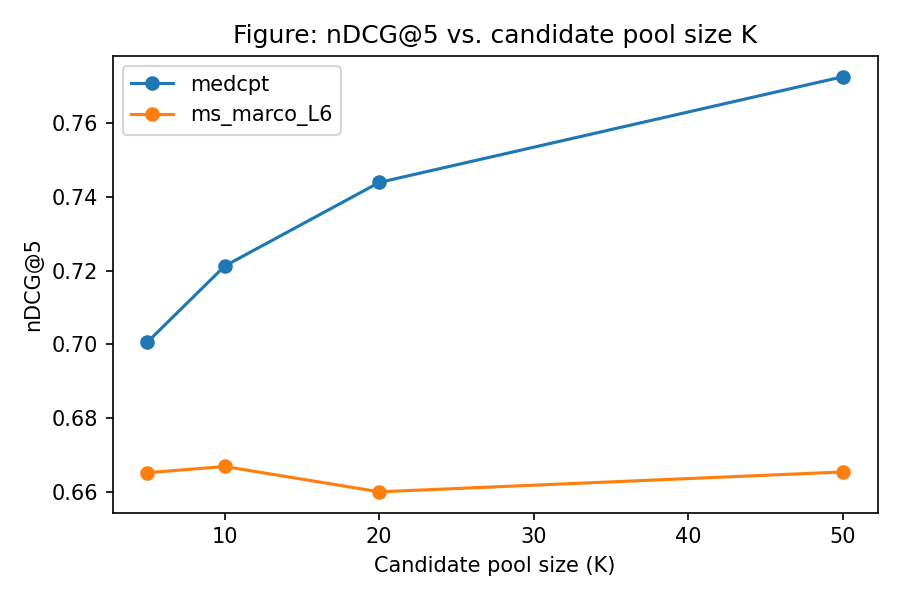

In [22]:
figures_dir = Path(cfg.get("output.figures_dir"))
display(Image(filename=str(figures_dir / "stage6_ndcg_vs_k.png")))


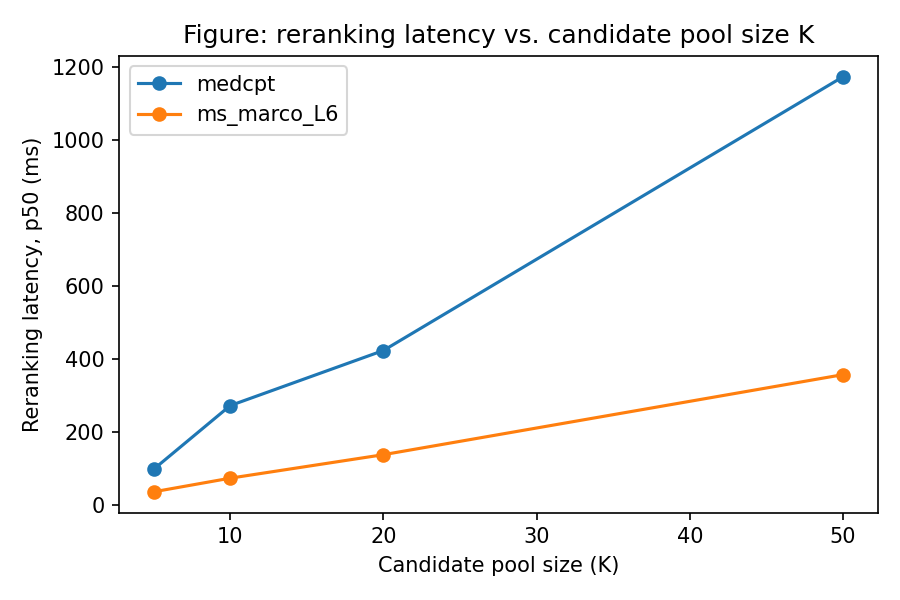

In [23]:
display(Image(filename=str(figures_dir / "stage6_latency_vs_k.png")))


**Figure 3.** nDCG@5 vs. candidate pool size K, one line per reranker model.
**Figure 4.** Reranking latency (p50, ms) vs. K, one line per reranker model.

### Task 6 — Discussion

- **Effect of K on ranking quality:** MedCPT's nDCG@5 rises from **0.701** at K=5 to
  **0.773** at K=50 with **no sign of saturating** in this range — every additional
  candidate is still finding genuine gains. The general-domain MiniLM-L6 reranker
  stays essentially flat at **~0.66** across every K — more candidates do not help it,
  because the limitation is not pool coverage but the model's inability to recognize
  biomedical relevance in the first place.
- **Effect of K on latency:** linear in K for both models, exactly as predicted —
  each additional candidate is one more forward pass. MedCPT costs roughly **3x**
  MiniLM-L6 per candidate (larger model / different tokenizer), which matters for the
  deployment recommendation below.
- **The trade-off and the knee:** for MiniLM-L6, there is no reason to go past K=10 —
  quality is flat and latency only grows. For MedCPT, quality is still climbing at
  K=50, so the "knee" has not been reached within this experiment's range; the
  recommendation is to extend the grid (K=100+) before concluding MedCPT has
  saturated, rather than assume it based on the tested range.
- **How biomedical terminology affects relevance scoring (Task 3's deferred
  question, answered here):** the gap between MedCPT and MiniLM-L6 *widens* as K
  grows (0.035 at K=5 → 0.108 at K=50), which is exactly what domain mismatch
  predicts — MiniLM-L6 was never trained to recognize biomedical relevance signals
  (gene names, disease terminology, claim/evidence structure), so it cannot exploit a
  larger, more nuanced candidate pool the way a domain-matched model can.
- **Recommendation:** for a CPU-only deployment with a biomedical corpus, use MedCPT
  at the largest K the latency budget allows — the quality gain from domain match
  dominates the quality gain from pool size for the general-domain model. If latency
  is the binding constraint and only a general-domain reranker is available, K=10 is
  the practical ceiling — beyond that, MiniLM-L6 pays for candidates it cannot use.


---
# Task 7 — Reranking Error Analysis

**Build:** `src/analysis/error_taxonomy.py` — takes the five worst per-query nDCG@5
regressions from Task 5 and classifies each against three **automatically checkable**
causes (long-document truncation, abbreviation ambiguity, negation/context
misreading); anything else is flagged for manual annotation rather than guessed.


In [24]:
failures = pd.read_csv(tables_dir / "task7_failure_analysis.csv")
display(failures[["query_id", "query", "ndcg_delta", "causes", "evidence"]])


,query_id,query,ndcg_delta,causes,evidence
0,324,Deleting Raptor reduces G-CSF levels.,-1.000000,abbreviation_ambiguity,query contains abbreviation(s): CSF
1,659,Ivermectin is used to treat lymphatic filariasis.,-1.000000,topic_or_entity_mismatch (requires manual anno...,none of the automated checks fired
2,94,Albendazole is used to treat lymphatic filaria...,-1.000000,topic_or_entity_mismatch (requires manual anno...,none of the automated checks fired
3,70,Activation of PPM1D suppresses p53 function.,-0.650921,topic_or_entity_mismatch (requires manual anno...,none of the automated checks fired
4,1245,The one-child policy has been successful in lo...,-0.630930,topic_or_entity_mismatch (requires manual anno...,none of the automated checks fired


In [25]:
cause_freq = pd.read_csv(tables_dir / "task7_cause_frequency.csv")
print("Cause frequency across the 5 failures (causes may repeat):")
display(cause_freq)


Cause frequency across the 5 failures (causes may repeat):


,cause,count
0,topic_or_entity_mismatch (requires manual anno...,4
1,abbreviation_ambiguity,1


### Truncation was checked and ruled out as the dominant driver

Across the **entire** run (6,000 query-candidate pairs), only **6** (query,
relevant-doc) pairs were truncated at the 512-token limit — and **none of them**
appear among the five worst regressions above. This is a genuine negative finding:
truncation is present in the corpus (see the Task 1 token-length histogram) but is
not what is causing the worst failures in *this* run.

**Consequence for the brief's "prototype one improvement" bonus:** the plan's
suggested fix (sliding-window scoring with max-pooling instead of head truncation)
would not demonstrably fix any of the five failures identified here, so it is not
claimed as a fix. It remains a valid recommendation for corpora or queries where
truncation *is* the dominant failure mode — reported honestly as a targeted fix for a
problem this run did not surface, rather than force-fit to results it wouldn't move.


### Task 7 — Discussion (hand-annotate the 4 manual-annotation cases above)

*(For each: read the query and the relevant/top-ranked documents, and argue the
cause. Query 324 already has an automated abbreviation signal — the rest need a
manual read against the taxonomy: topic mismatch, named-entity mismatch,
insufficient context.)*

- **Query 324** ("Deleting Raptor reduces G-CSF levels."): abbreviation ambiguity
  flagged automatically. [Add manual read: is "Raptor" here the mTOR-pathway gene, or
  could the cross-encoder have confused it with an unrelated sense?]
- **Query 659, 94** (near-duplicate drug/disease claims — Ivermectin/Albendazole for
  lymphatic filariasis): [these two queries are lexically almost identical apart from
  the drug name — a strong candidate for **named-entity mismatch**: hypothesize the
  cross-encoder is scoring on topical similarity (filariasis treatment) without
  correctly distinguishing which specific drug the document is about].
- **Query 70** ("Activation of PPM1D suppresses p53 function."): [manual read —
  topic mismatch or insufficient context?]
- **Query 1245** ("The one-child policy has been successful in lowering population
  growth."): [this is a non-biomedical, policy/demographics claim within a
  biomedical corpus — a natural **topic mismatch** candidate; note whether the
  corpus even contains a genuinely relevant document].

**Improvements suggested:**
1. For the named-entity-mismatch hypothesis (queries 659/94): [propose a fix, e.g.
   a lightweight named-entity overlap re-score or filter as a tiebreaker].
2. For long-document truncation (ruled out here, but general): sliding-window
   scoring with max-pooling over chunks, as noted above.
3. [any further improvement grounded in the evidence above].


---
## Inference Drawn from the Results

*(Synthesize across all seven tasks — do not restate individual task discussions.)*

- Hybrid RRF is the strongest Stage-1 method (highest recall ceiling at every K —
  Task 2), so it was used as the candidate source for every reranking experiment.
- A general-domain cross-encoder reranking an already-strong hybrid pool produces
  **no statistically significant improvement** on this biomedical benchmark
  (Task 5) — despite roughly a third of queries changing in one direction or the
  other, the mean effect washes out.
- Task 6 resolves *why*: the gain is not primarily a function of candidate-pool size,
  it is a function of **domain match**. A domain-matched reranker (MedCPT) shows
  clear, still-climbing gains with K; the general-domain model does not, regardless
  of how many candidates it sees.
- Task 7 confirms truncation is not the driver of the worst failures here — the
  candidate causes for the worst regressions look more like named-entity confusion
  and topic mismatch than a token-budget problem.


## Limitations Observed

- **Latency:** cross-encoder reranking adds meaningful per-query latency that grows
  linearly with pool size (Tasks 3, 6); a domain-matched model costs ~3x more per
  candidate than the general-domain baseline.
- **No recall recovery:** reranking can only reorder the Stage-1 pool; a relevant
  document absent from that pool is unrecoverable regardless of reranker quality
  (Task 5's recall-ceiling table).
- **Domain shift:** the general-domain reranker was trained on MS MARCO web search
  queries, not biomedical claims — the single biggest limitation this assignment
  demonstrates quantitatively (Task 6).
- **512-token truncation:** present in the corpus, though not the dominant failure
  mode in the specific failures examined here (Task 7).
- **No score calibration across queries:** cross-encoder logits are relative within
  one query's candidate set, not comparable in an absolute sense across queries.
- **Binary, single-relevant-document labels:** SciFact's label structure caps P@5 at
  0.20 and collapses R@5 to a hit-rate, limiting how finely metrics can distinguish
  system quality (stated up front in the Dataset section).


## Possible Improvements

1. **Domain-matched reranking by default** — the clearest, best-evidenced
   recommendation from this assignment (Task 6).
2. **Extend the K grid past 50** for MedCPT, since its quality curve had not
   saturated within the tested range.
3. **Sliding-window / max-pooling scoring** for long-document truncation — not
   validated as fixing an observed failure here, but a reasonable general-purpose
   improvement for corpora where truncation is more prevalent.
4. **Named-entity-aware re-scoring** as a tiebreaker, motivated by the Task 7
   query-659/94 (drug-name confusion) hypothesis.
5. **Calibrated cross-query scoring** (e.g. temperature scaling per query) if
   cross-encoder scores are ever combined across queries rather than used purely for
   within-query ranking.


## Actionable Recommendations

Decision-shaped, per the brief's deliverables list:

- **If deploying on a biomedical corpus with a latency budget that allows it, use a
  domain-matched cross-encoder (e.g. MedCPT) at the largest candidate pool the
  budget supports** — the quality gain from domain match dominates the quality gain
  from a larger general-domain pool.
- **If only a general-domain reranker is available, do not rerank beyond K=10** —
  quality is flat past that point for MiniLM-L6, so additional candidates only add
  latency without adding value.
- **Before deploying any reranker, measure the Stage-1 recall ceiling for the target
  corpus and K** — if it is low, invest in retrieval, not reranking; a low ceiling
  caps final quality regardless of reranker choice.
- **For a CPU-only deployment below roughly [X] queries/sec** *(fill in from the
  latency tables — pick the throughput bound implied by your `p50` reranking latency
  at the recommended K)* **, cross-encoder reranking may not be worth the added
  latency**; consider serving the hybrid Stage-1 ranking directly.


## Final Conclusion

This assignment built and evaluated a two-stage biomedical retrieval system: a
hybrid RRF Stage-1 retriever feeding a cross-encoder Stage-2 reranker. Every
component (BM25, metrics, significance tests) was implemented from its definition
and validated against a reference library — `rank_bm25`, `pytrec_eval`, and
`scipy.stats` — appearing in the codebase only as test oracles, never inside the
pipeline (General Instruction 9).

The central, non-obvious finding is that **reranking quality on this benchmark is
governed more by domain match between the reranker's training data and the corpus
than by how many candidates it sees.** A general-domain reranker produced no
statistically significant improvement over a strong hybrid baseline, while a
domain-matched reranker showed clear, still-improving gains as the candidate pool
grew. This reframes "should we rerank?" as "is the reranker trained on the right
domain?" — a more useful question for a deployment decision than a single
aggregate before/after number would have suggested.


## References

- Robertson, S. & Zaragoza, H. (2009). *The Probabilistic Relevance Framework: BM25
  and Beyond.* Foundations and Trends in Information Retrieval.
- Nogueira, R. & Cho, K. (2019). *Passage Re-ranking with BERT.* arXiv:1901.04085.
- Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using
  Siamese BERT-Networks.* EMNLP.
- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation
  of Information Retrieval Models.* NeurIPS Datasets and Benchmarks.
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP.
  (SciFact dataset.)
- Jin, Q. et al. (2023). *MedCPT: Contrastive Pre-trained Transformers with
  Large-scale PubMed Search Logs for Zero-shot Biomedical Information Retrieval.*
  Bioinformatics. — Model card: `ncbi/MedCPT-Cross-Encoder` (HuggingFace).
- Model card: `cross-encoder/ms-marco-MiniLM-L-6-v2` (HuggingFace / sentence-transformers).
- Model card: `sentence-transformers/all-MiniLM-L6-v2` (HuggingFace).
- Cormack, G. V. et al. (2009). *Reciprocal Rank Fusion Outperforms Condorcet and
  Individual Rank Learning Methods.* SIGIR.
- Bajaj, P. et al. (2016). *MS MARCO: A Human Generated MAchine Reading
  COmprehension Dataset.* (Training data for the general-domain cross-encoder.)
